In [29]:
# =============================
# IMPORT LIBRARIES
# =============================
import pandas as pd

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

In [30]:
class DataProcessor:
    def __init__(self, path):
        self.path = path
        self.df = None
        self.X = None
        self.y = None

    def load_data(self):
        self.df = pd.read_csv(self.path)
        print(self.df.head())
        print(self.df.info())
        return self.df

    def clean_data(self):
        df = self.df.copy()

        # =============================
        # 1. Handle Missing Values
        # =============================
        missing_values = df.isnull().sum()
        print("Missing Values:\n", missing_values)

        # Numeric columns → mean imputation
        num_cols = df.select_dtypes(include=['number']).columns
        df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

        # Categorical columns → mode imputation
        cat_cols = df.select_dtypes(include=['object']).columns
        for col in cat_cols:
            df[col] = df[col].fillna(df[col].mode()[0])

        # =============================
        # 2. Remove Duplicates
        # =============================
        df = df.drop_duplicates()

        # =============================
        # 3. Drop Irrelevant Columns
        # =============================
        df = df.drop(
            columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'],
            errors='ignore'
        )

        # =============================
        # 4. Clean Target Column
        # =============================
        df['Attrition'] = df['Attrition'].astype(str).str.strip()
        df = df[df['Attrition'].isin(['Yes', 'No'])]

        # =============================
        # 5. Encode Simple Binary Column
        # =============================
        if 'Sex' in df.columns:
            df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

        # =============================
        # Save cleaned dataframe
        # =============================
        self.df = df

        return df
    
    def eda_visualization(self):
        print(self.df['Attrition'].value_counts())
        self.df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%')
        plt.show()

    def feature_engineering(self):
        self.df['Attrition_Numeric'] = self.df['Attrition'].map({'No':0,'Yes':1})

    def plot_correlation_heatmap(self):

        # Ensure Attrition_Numeric exists
        if 'Attrition_Numeric' not in self.df.columns:
            self.df['Attrition_Numeric'] = self.df['Attrition'].map({'No': 0, 'Yes': 1})

        key_features = [
            'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
            'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
            'DistanceFromHome', 'Attrition_Numeric'
        ]

        key_features = [col for col in key_features if col in self.df.columns]
        corr_matrix = self.df[key_features].corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(
            corr_matrix,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            square=True
        )

        plt.title('Correlation Heatmap of Key Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def get_data(self):
        y = self.df['Attrition_Numeric'] # use engineered column
        X = self.df.drop(columns=['Attrition', 'Attrition_Numeric'], errors='ignore')
        return X, y
    
   

In [32]:
class ModelBuilder:
    def __init__(self, X):
        self.X = X

    def build_preprocessor(self):

        categorical_cols = self.X.select_dtypes(include=['object']).columns.tolist()
        numeric_cols = self.X.select_dtypes(include=['int64','float64']).columns.tolist()

        preprocessor = ColumnTransformer([
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

        return preprocessor

    def get_models(self):

        models = {
            "SVM": SVC(probability=True,
                       C=1.0,
                        gamma='scale',
                        class_weight='balanced',
                        random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=500, 
                                                    max_depth=None,
                                                    min_samples_split=5,
                                                    min_samples_leaf=2,
                                                    class_weight='balanced',
                                                    random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.05,
                                                            max_depth=3,
                                                            random_state=42)
        }

        return models

In [33]:
class ModelEvaluator:
    def __init__(self, models, preprocessor):
        self.models = models
        self.preprocessor = preprocessor
        self.results = []

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):

        best_model = None
        best_score = -1
        best_model_name = None

        for name, model in self.models.items():

            pipeline = Pipeline([
                ('preprocessing', self.preprocessor),
                ('model', model)
            ])

            # ======================
            # TRAIN MODEL
            # ======================
            pipeline.fit(X_train, y_train)

            # ======================
            # PREDICTIONS
            # ======================
            y_proba = pipeline.predict_proba(X_test)[:, 1]
            y_pred = (y_proba > 0.3).astype(int)

            # ======================
            # METRICS
            # ======================
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc = roc_auc_score(y_test, y_proba)
            pr_auc = average_precision_score(y_test, y_proba)

            cm_train = confusion_matrix(y_train, pipeline.predict(X_train))
            cm_test = confusion_matrix(y_test, y_pred)

            # ======================
            # STORE RESULTS
            # ======================
            self.results.append({
                "Model": name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1,
                "ROC-AUC": roc,
                "PR-AUC": pr_auc,
                "confusion_matrix_train": cm_train,
                "confusion_matrix_test": cm_test
            })

            # ======================
            # NEW BEST MODEL SCORE
            # Weighted combination:
            # Recall (50%), F1 (30%), ROC-AUC (20%)
            # ======================
            combined_score = (0.5 * rec) + (0.3 * f1) + (0.2 * roc)

            if combined_score > best_score:
                best_score = combined_score
                best_model = pipeline
                best_model_name = name

        return self.results, best_model, best_model_name

    def evaluate(self, model, X_test, y_test):

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        report_df = X_test.copy()
        report_df["Actual"] = y_test.values
        report_df["Attrition_Prob"] = y_proba
        report_df["Predicted"] = y_pred

        report_df["Risk_Level"] = pd.cut(
            y_proba,
            bins=[0, 0.3, 0.6, 1.0],
            labels=["Low Risk", "Medium Risk", "High Risk"]
        )

        print("\n📊 HR RISK DISTRIBUTION:")
        print(report_df["Risk_Level"].value_counts())

        print("\n📌 Attrition Rate by Risk Level:")
        print(report_df.groupby("Risk_Level")["Actual"].mean())

        print("\n🔴 TOP 5 HIGH RISK EMPLOYEES:")
        print(
            report_df.sort_values("Attrition_Prob", ascending=False)
            .head(5)[["Attrition_Prob", "Risk_Level"]]
        )

        numeric_corr = report_df.corr(numeric_only=True)["Actual"].sort_values()

        print("\n📌 Key Attrition Drivers:")
        print("\nTop Risk Factors:")
        print(numeric_corr.tail(5))

        print("\nProtective Factors:")
        print(numeric_corr.head(5))

        return report_df

In [34]:
class ReportGenerator:
    def __init__(self, results, df=None):
        self.results = results
        self.df = pd.DataFrame(results)
        self.df_cleaned = df

    def final_report(self):
        print(self.df)

    def plot_confusion_matrices(self):

        for r in self.results:

            plt.figure()
            sns.heatmap(r['confusion_matrix_train'], annot=True, fmt='d')
            plt.title(r['Model'] + " Train CM")
            plt.show()

            plt.figure()
            sns.heatmap(r['confusion_matrix_test'], annot=True, fmt='d', cmap='Reds')
            plt.title(r['Model'] + " Test CM")
            plt.show()

    def save_reports(self):
        self.df.to_csv("model_report.csv", index=False)
    
    def save_cleaned_data(self, path="data/cleaned_employee_attrition.csv"):
        if self.df_cleaned is None:
            raise ValueError("No cleaned dataset provided")
        
        self.df_cleaned.to_csv(path, index=False)
        print(f"Cleaned data saved to {path}")

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

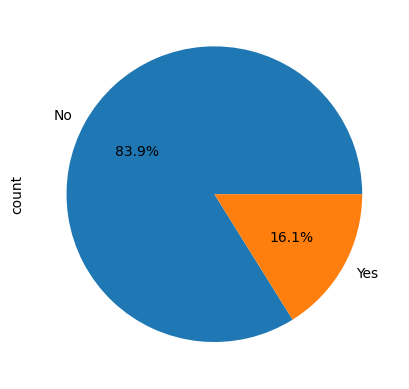

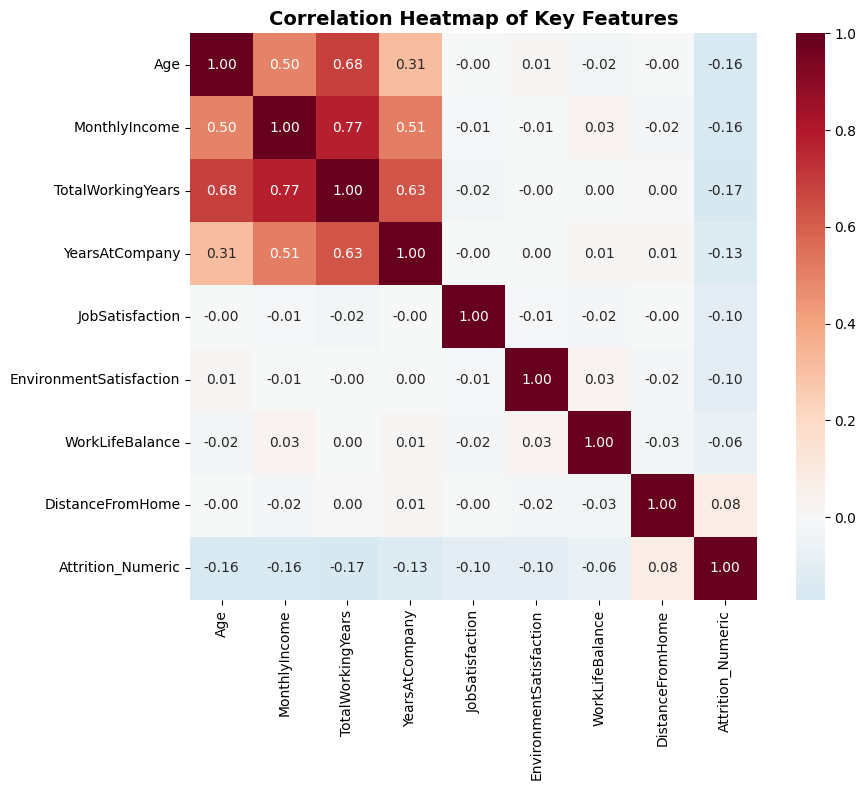


📊 HR RISK DISTRIBUTION:
Risk_Level
Low Risk       241
Medium Risk     36
High Risk       17
Name: count, dtype: int64

📌 Attrition Rate by Risk Level:
Risk_Level
Low Risk       0.087137
Medium Risk    0.361111
High Risk      0.764706
Name: Actual, dtype: float64

🔴 TOP 5 HIGH RISK EMPLOYEES:
     Attrition_Prob Risk_Level
357        0.923953  High Risk
911        0.888170  High Risk
688        0.885017  High Risk
762        0.848979  High Risk
301        0.764567  High Risk

📌 Key Attrition Drivers:

Top Risk Factors:
DistanceFromHome    0.040668
HourlyRate          0.044646
Predicted           0.446942
Attrition_Prob      0.510422
Actual              1.000000
Name: Actual, dtype: float64

Protective Factors:
JobLevel                -0.180605
MonthlyIncome           -0.158062
JobInvolvement          -0.149344
YearsInCurrentRole      -0.136652
TrainingTimesLastYear   -0.131820
Name: Actual, dtype: float64

🏆 Best Model: SVM
Model saved as model.pkl
🏆 In Pickle file Best Model Name: SVM

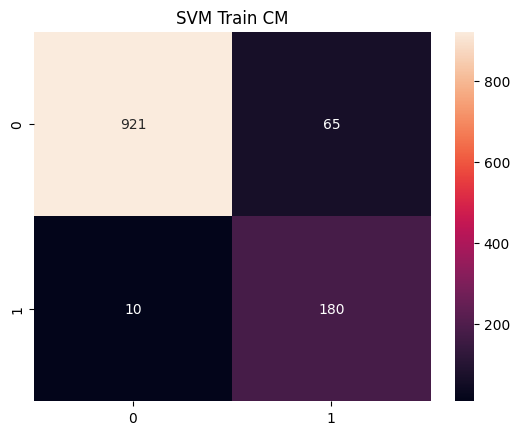

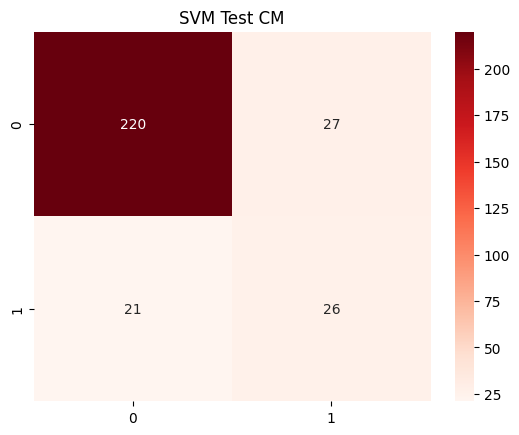

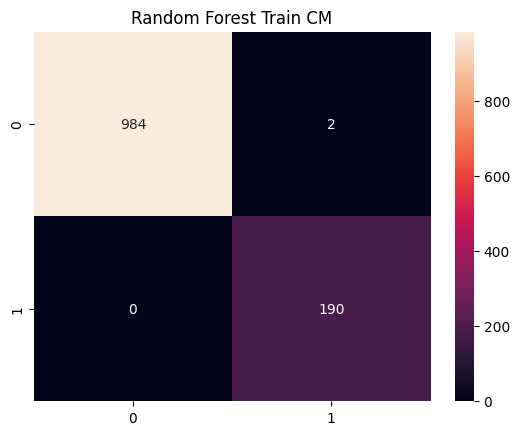

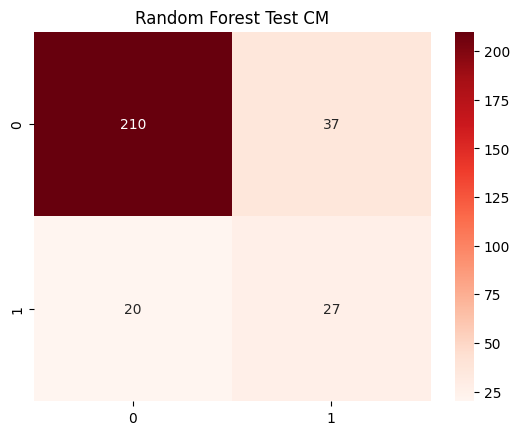

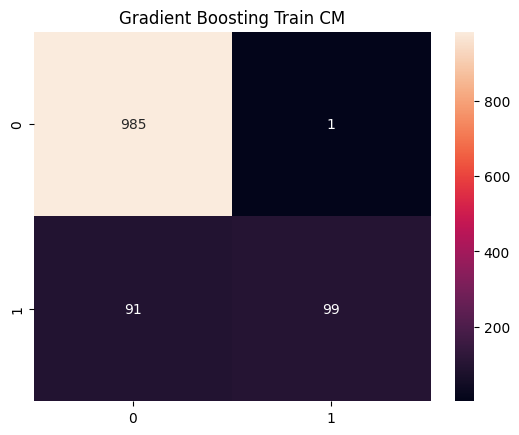

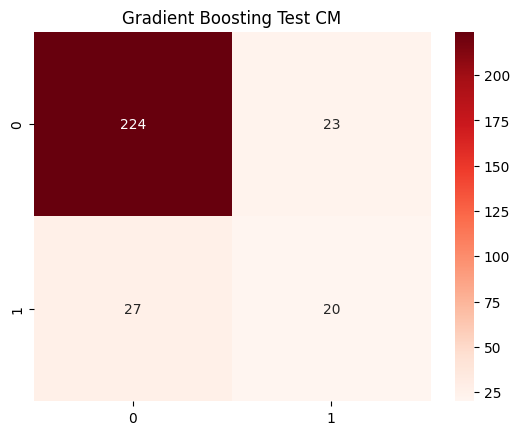

Cleaned data saved to data/cleaned_employee_attrition.csv


In [35]:
def main():

    dp = DataProcessor('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    dp.load_data()
    dp.clean_data()
    dp.eda_visualization()
    dp.feature_engineering()
    dp.plot_correlation_heatmap()

    X, y = dp.get_data()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    mb = ModelBuilder(X)
    preprocessor = mb.build_preprocessor()
    models = mb.get_models()

    evaluator = ModelEvaluator(models, preprocessor)

    # ✅ FIX: capture model name too
    results, best_model, best_model_name = evaluator.train_and_evaluate(
        X_train, X_test, y_train, y_test
    )

    report_df = evaluator.evaluate(best_model, X_test, y_test)

    print("\n🏆 Best Model:", best_model_name)

    # =========================
    # SAVE MODEL + NAME
    # =========================
    artifact = {
        "model": best_model,
        "model_name": best_model_name
    }

    with open("model.pkl", "wb") as f:
        pickle.dump(artifact, f)

    print("Model saved as model.pkl")


    with open("model.pkl", "rb") as f:
        artifact = pickle.load(f)

    print("🏆 In Pickle file Best Model Name:", artifact["model_name"])

    # =========================
    # REPORTING
    # =========================
    report = ReportGenerator(results, dp.df)
    report.final_report()
    report.plot_confusion_matrices()
    report.save_reports()
    report.save_cleaned_data()


if __name__ == "__main__":
    main()